In [3]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import warnings
import glob
warnings.filterwarnings('ignore')
from jupyterthemes import jtplot
jtplot.style()
from sklearn import metrics

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn import svm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import random

def pyRandColor():
    randNums = [random.random() for _ in range(0, 3)]

    RGB255 = list([ int(i * 255) for i in randNums ])
    RGB1 = list([ round(i, 2) for i in randNums ])
    return RGB1


## Data

In [4]:
def getData(filepath, varname='human', cols=['perplexity', 'percentage', 'entropy_rate', 'rates']):
    """
    Load and process a CSV file where the 'rates' column contains stringified lists.

    This function reads the specified columns from the CSV file, converts the 'rates' 
    column from string to list, expands each element of the list into separate columns,
    and adds a new column indicating the data category.

    Parameters:
        filepath (str): Path to the CSV file to load.
        varname (str, optional): Label for the dataset, assigned to a new 'category' column. Default is 'human'.
        cols (list of str, optional): List of columns to load from the CSV. Must include 'rates'. 
                                      Default is ['perplexity', 'percentage', 'entropy_rate', 'rates'].

    Returns:
        pd.DataFrame: Processed DataFrame with expanded 'rates' columns and a 'category' column.
    """
    import pandas as pd
    import ast  # For safely evaluating strings as Python objects

    df = pd.read_csv(filepath)[cols]
    df['rates'] = df['rates'].apply(ast.literal_eval)

    # Expand the 'rates' list into separate columns
    rates_df = df['rates'].apply(pd.Series)
    rates_df.columns = [f'rates_{i}' for i in rates_df.columns]

    # Combine expanded 'rates' columns with the rest of the DataFrame
    df_expanded = pd.concat([df.drop(columns=['rates']), rates_df], axis=1)

    return df_expanded.assign(label=varname)


## Recognition without training using averged estimate of entropy rate

In [7]:
PATH='/home/ishanu/Dropbox/ZED/Research/recogai_new/'

human1=getData(PATH+'/nero/nero-data/table_data/gutenberg/gutenberg_detection.csv',varname=0)
human2=getData(PATH+'/nero/nero-data/table_data/arxiv_entropy/arxiv_table.csv',varname=0)
ai0=getData(PATH+'/nero/nero-data/table_data/gpt4o/gpt_4o_detection.csv',varname=1)
ai1=getData(PATH+'/nero/nero-data/table_data/ai_longform_gpt4o/ai_web_longform_table.csv',varname=1)
ai2=getData(PATH+'/nero/nero-data/table_data/ai_longform_gpt3.5/gpt_35_table.csv',varname=1)
ai3=getData(PATH+'/nero/nero-data/table_data/ai_longform_gpt4.0/gpt_40_table.csv',varname=1)
ai4=getData(PATH+'/nero/nero-data/table_data/claude_sonnet_40/claude_detection.csv',varname=1)
ai5=getData(PATH+'/nero/nero-data/table_data/gemini_25_pro/gemini_25_detection.csv',varname=1)
ai6=getData(PATH+'/nero/nero-data/table_data/gpt5/gpt_5_detection.csv',varname=1)
#ai7=getData('../nero/nero-data/table_data_new/web_article/ai_article_table.csv',varname=1)
#ai8=getData('../nero/nero-data/table_data_new/web_novel/ai_web_doped_table.csv',varname=1)
dallhuman=pd.concat([human1,human2])

df=pd.concat([human1,human2,ai0,ai1,ai2,ai3, ai4,ai5,ai6])
#df=pd.concat([human1,human2,ai1,])
NAMES={'human1':'Gutenberg project',
       'human2':'Arxiv papers',
       'ai0':'API-GPT-4o',
       'ai1':'AI Generated GPT-4o',
       'ai2':'AI Generated GPT-3.5',
       'ai3':'AI Generated GPT-4.0',
       'ai4':'Claude',
       'ai5':'Gemini',
       'ai6':'GPT-5',    
      }

In [8]:
#dh=df.copy()
df_=df.copy()
df_['nz_entropy_rate']=df[[x for x in df_.columns if 'rates' in x]].replace(0,None).median(axis=1)

def func1(row):
    n=0
    for i in row.values:
        if i == 0:
            n=n+1
    return n
nz=(df!=0).iloc[:,3:43].mean(axis=1)
nzstd=(df!=0).iloc[:,3:43].std(axis=1)
df_['nzmean'] = nz
df_['nzstd'] = nzstd
df_['nzero'] = df.apply(func1,axis=1)
#df=df.drop('nzero',axis=1)

In [9]:
ytrue=df_.label.values
ypred= df_.fillna(0).nz_entropy_rate.values #+ df.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr, tpr, thresholds = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e=auc(fpr, tpr)
print('nzent',auc_e)
D1=pd.DataFrame({'fpr':fpr,'tpr':tpr,'threshold':thresholds}).set_index('threshold').sort_index().dropna()
#D1.to_csv('./src/neroroce.csv')

ypred=  df_.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr2, tpr2, thresholds2 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e2=auc(fpr2, tpr2)
print(auc_e2)
D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2]).to_csv('neroroce.csv')


ypred=  df_.fillna(0).nzero.values
#y_pred=np.median(X,axis=1)
fpr3, tpr3, thresholds3 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e3=auc(fpr3, tpr3)
print(auc_e3)
D3=pd.DataFrame({'fpr':fpr3,'tpr':tpr3,'threshold':thresholds3}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2,D3]).to_csv('neroroce.csv')



ypred=  df_.fillna(0).perplexity.values
#y_pred=np.median(X,axis=1)
fprP, tprP, thresholdsP = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_P=auc(fprP, tprP)
print('px',auc_P)
DP=pd.DataFrame({'fpr':fprP,'tpr':tprP,'threshold':thresholdsP}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


ypred=  df_.fillna(0).percentage.values
#y_pred=np.median(X,axis=1)
fprPc, tprPc, thresholdsPc = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_Pc=auc(fprPc, tprPc)
print('%->',auc_Pc)
DPc=pd.DataFrame({'fpr':fprPc,'tpr':tprPc,'threshold':thresholdsPc}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


nzent 0.7847100021156452
0.6058922767467996
0.6297656592604504
px 0.8208906328148864
%-> 0.9447069175214702


In [11]:
from zedstat import zedstat 
zte=zedstat.processRoc(df=pd.read_csv('neroroce.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

zte.smooth(STEP=0.001)
zte.allmeasures(interpolate=True)
zte.usample(precision=2)
zte.getBounds()

auc_e=np.array(zte.auc(alpha=.05))*100
deltae=(auc_e[1]-auc_e[2])/2
le=str(auc_e[0])[:4]+'%'
zte.auc(alpha=.05)

(0.719215336853427,
 np.float64(0.7321955043922224),
 np.float64(0.7062351693146316))

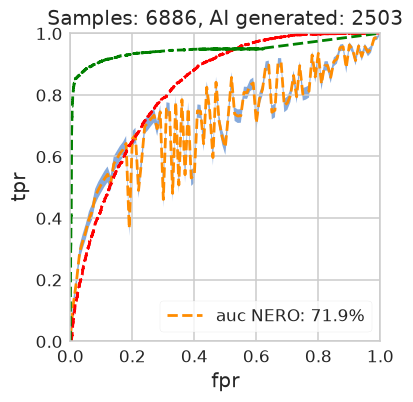

In [12]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
#ax=ztz.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)

#plt.fill_between(x=ztz.get().index, y1=ztz.df_lim['U'].tpr,y2=ztz.df_lim['L'].tpr, alpha=.6)
DP.sort_values('tpr').set_index('fpr').tpr.plot(style='--',ax=ax,color='red',lw=2)
DPc.sort_values('tpr').set_index('fpr').tpr.plot(style='--',ax=ax,color='green',lw=2)

#DP.to_csv('perplexity_all.csv')
#DPc.to_csv('percentage_all.csv')

ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO: '+le],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining1.pdf',bbox_inches='tight',transparent=True)

In [13]:
#dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
#dx.to_csv('nero_all_notraining.csv')

In [14]:
from sklearn import metrics
df_all=pd.concat([human1,human2,ai0,ai1,ai2,ai3,ai4,ai5,ai6])
SUBSET='ALL'

In [15]:
#dh=df.copy()
df_=df_all.copy()
df_['nz_entropy_rate']=df_[[x for x in df_.columns if 'rates' in x]].replace(0,None).median(axis=1)

def func1(row):
    n=0
    for i in row.values:
        if i == 0:
            n=n+1
    return n
nz=(df_!=0).iloc[:,3:43].mean(axis=1)
nzstd=(df_!=0).iloc[:,3:43].std(axis=1)
df_['nzmean'] = nz
df_['nzstd'] = nzstd
df_['nzero'] = df_.apply(func1,axis=1)

In [16]:
ytrue=df_.label.values
ypred= df_.fillna(0).nz_entropy_rate.values #+ df.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr, tpr, thresholds = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e=auc(fpr, tpr)
print('nzent',auc_e)
D1=pd.DataFrame({'fpr':fpr,'tpr':tpr,'threshold':thresholds}).set_index('threshold').sort_index().dropna()
#D1.to_csv('./src/neroroce.csv')

ypred=  df_.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr2, tpr2, thresholds2 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e2=auc(fpr2, tpr2)
print(auc_e2)
D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2]).to_csv('neroroce_frac.csv')


ypred=  df_.fillna(0).nzero.values
#y_pred=np.median(X,axis=1)
fpr3, tpr3, thresholds3 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e3=auc(fpr3, tpr3)
print(auc_e3)
D3=pd.DataFrame({'fpr':fpr3,'tpr':tpr3,'threshold':thresholds3}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2,D3]).to_csv('neroroce_frac.csv')



ypred=  df_.fillna(0).perplexity.values
#y_pred=np.median(X,axis=1)
fprP, tprP, thresholdsP = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_P=auc(fprP, tprP)
print('px',auc_P)
DP=pd.DataFrame({'fpr':fprP,'tpr':tprP,'threshold':thresholdsP}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')
DP.to_csv('perplexity_frac.csv')


ypred=  df_.fillna(0).percentage.values
#y_pred=np.median(X,axis=1)
fprPc, tprPc, thresholdsPc = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_Pc=auc(fprPc, tprPc)
print('%->',auc_Pc)
DPc=pd.DataFrame({'fpr':fprPc,'tpr':tprPc,'threshold':thresholdsPc}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
DPc = DPc[~np.isinf(DPc.index)]
DPc.to_csv('percentage_frac.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


nzent 0.7847100021156452
0.6058922767467996
0.6388400084625805
px 0.8208906328148864
%-> 0.9447069175214702


In [17]:
from zedstat import zedstat 
zte=zedstat.processRoc(df=pd.read_csv('neroroce_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

zte.smooth(STEP=0.001)
zte.allmeasures(interpolate=True)
zte.usample(precision=2)
zte.getBounds()

auc_e=np.array(zte.auc(alpha=.05))*100
deltae=(auc_e[1]-auc_e[2])/2
le=str(auc_e[0])[:4]+'%'
zte.auc(alpha=.05)


ztpc=zedstat.processRoc(df=pd.read_csv('percentage_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

ztpc.smooth(STEP=0.001)
ztpc.allmeasures(interpolate=True)
ztpc.usample(precision=2)
ztpc.getBounds()

auc_pc=np.array(ztpc.auc(alpha=.05))*100
deltapc=(auc_pc[1]-auc_pc[2])/2
lpc=str(auc_pc[0])[:4]+'%'
ztpc.auc(alpha=.05)



ztpx=zedstat.processRoc(df=pd.read_csv('perplexity_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

ztpx.smooth(STEP=0.001)
ztpx.allmeasures(interpolate=True)
ztpx.usample(precision=2)
ztpx.getBounds()

auc_px=np.array(ztpx.auc(alpha=.05))*100
deltapx=(auc_px[1]-auc_px[2])/2
lpx=str(auc_px[0])[:4]+'%'
ztpx.auc(alpha=.05)

(0.8210302770009322,
 np.float64(0.8320414349695301),
 np.float64(0.8100191190323344))

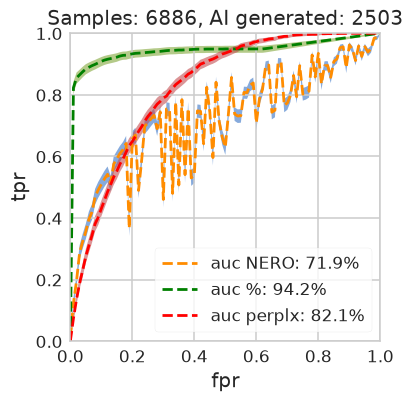

In [18]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
ax=ztpc.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
ax=ztpx.get().tpr.plot(style='--',ax=ax,color='red',lw=2)

plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpc.get().index, y1=ztpc.df_lim['U'].tpr,y2=ztpc.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpx.get().index, y1=ztpx.df_lim['U'].tpr,y2=ztpx.df_lim['L'].tpr, alpha=.6)


dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_notraining.csv')
dx=pd.DataFrame({'tpr_upper':ztpc.df_lim['U'].tpr,'tpr_lower':ztpc.df_lim['L'].tpr}).join(ztpc.get()['tpr'])
dx.to_csv('percentage_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztpx.df_lim['U'].tpr,'tpr_lower':ztpx.df_lim['L'].tpr}).join(ztpx.get()['tpr'])
dx.to_csv('perplexity_'+SUBSET+'.csv')


ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO: '+le,'auc %: '+lpc,'auc perplx: '+lpx],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining'+SUBSET+'.pdf',bbox_inches='tight',transparent=True)

# AUC distribution for subsets

In [20]:
import itertools
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import auc as sk_auc
from zedstat import zedstat
from tqdm import tqdm

def _roc_df_from_scores(ytrue, yscore, *, pos_label):
    fpr, tpr, thr = metrics.roc_curve(ytrue, yscore, pos_label=pos_label)
    df = pd.DataFrame({"threshold": thr, "fpr": fpr, "tpr": tpr}).dropna()
    # Keep finite only
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df


def _dedupe_by_fpr_keep_max_tpr(df: pd.DataFrame) -> pd.DataFrame:
    # zedstat later indexes by fpr; ensure enough unique fpr points
    df = df.sort_values("fpr")
    df = df.groupby("fpr", as_index=False)["tpr"].max()
    return df.sort_values("fpr")


def _zedstat_auc_from_roc_df(
    roc_df: pd.DataFrame,
    *,
    total_samples: int,
    positive_samples: int,
    prevalence: float,
    alpha_process: float,
    alpha_auc: float,
    smooth_step: float,
    order: int,
):
    """
    Returns (auc_percent, used_order, method_str).
    Falls back to sklearn AUC if zedstat spline bounds are impossible.
    """
    roc_df = roc_df[["fpr", "tpr"]].copy()
    roc_df = _dedupe_by_fpr_keep_max_tpr(roc_df)

    n_unique = roc_df["fpr"].nunique()
    if n_unique < 2:
        # Not even a curve
        return float("nan"), None, "nan"

    # pick a safe spline order for zedstat's spline interpolation
    safe_order = min(order, n_unique - 1)
    if safe_order < 1:
        # linear AUC directly
        return float(sk_auc(roc_df["fpr"].values, roc_df["tpr"].values) * 100.0), 1, "sklearn"

    try:
        zt = zedstat.processRoc(
            df=roc_df,
            order=safe_order,
            total_samples=total_samples,
            positive_samples=positive_samples,
            alpha=alpha_process,
            prevalence=prevalence,
        )
        zt.smooth(STEP=smooth_step)
        zt.allmeasures(interpolate=True)
        zt.usample(precision=2)
        zt.getBounds()
        auc_val = float(np.array(zt.auc(alpha=alpha_auc))[0] * 100.0)
        return auc_val, safe_order, "zedstat"
    except Exception:
        # final fallback: compute AUC directly from the deduped ROC
        return float(sk_auc(roc_df["fpr"].values, roc_df["tpr"].values) * 100.0), safe_order, "sklearn"


def compute_auc_triple_for_df(
    df_gpt5: pd.DataFrame,
    *,
    label_col: str = "label",
    entropy_rate_col: str = "entropy_rate",
    perplexity_col: str = "perplexity",
    percentage_col: str = "percentage",
    rates_col_substring: str = "rates",
    nz_slice: tuple[int, int] = (3, 43),
    prevalence: float = 0.5,
    alpha_process: float = 0.01,
    alpha_auc: float = 0.05,
    smooth_step: float = 0.001,
    order: int = 3,
    require_both_classes: bool = True,
):
    df_ = df_gpt5.copy()

    if label_col not in df_.columns:
        raise ValueError(f"Missing label column: '{label_col}'")

    ytrue = df_[label_col].values

    if require_both_classes and len(np.unique(ytrue)) < 2:
        # cannot define ROC/AUC
        return (np.nan, np.nan, np.nan)

    # nz_entropy_rate
    rate_cols = [c for c in df_.columns if rates_col_substring in c]
    if not rate_cols:
        raise ValueError(f"No columns found containing substring '{rates_col_substring}'")
    df_["nz_entropy_rate"] = df_[rate_cols].replace(0, None).median(axis=1)

    # nzero across row (as in your code)
    def func1(row):
        n = 0
        for i in row.values:
            if i == 0:
                n += 1
        return n

    lo, hi = nz_slice
    df_["nzmean"] = (df_ != 0).iloc[:, lo:hi].mean(axis=1)
    df_["nzstd"] = (df_ != 0).iloc[:, lo:hi].std(axis=1)
    df_["nzero"] = df_.apply(func1, axis=1)

    total_samples = len(ytrue)
    positive_samples = int(np.sum(ytrue))

    # --- “neroroce” composite: D1 + D2 + D3 (all with pos_label=0) ---
    roc1 = _roc_df_from_scores(ytrue, df_.fillna(0)["nz_entropy_rate"].values, pos_label=0)
    roc2 = _roc_df_from_scores(ytrue, df_.fillna(0)[entropy_rate_col].values, pos_label=0)
    roc3 = _roc_df_from_scores(ytrue, df_.fillna(0)["nzero"].values, pos_label=0)

    neroroce = pd.concat([roc1[["fpr", "tpr"]], roc2[["fpr", "tpr"]], roc3[["fpr", "tpr"]]], axis=0)
    auc_e, _, _ = _zedstat_auc_from_roc_df(
        neroroce,
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    # --- percentage (pos_label=1) ---
    roc_pc = _roc_df_from_scores(ytrue, df_.fillna(0)[percentage_col].values, pos_label=1)
    auc_pc, _, _ = _zedstat_auc_from_roc_df(
        roc_pc[["fpr", "tpr"]],
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    # --- perplexity (pos_label=1) ---
    roc_px = _roc_df_from_scores(ytrue, df_.fillna(0)[perplexity_col].values, pos_label=1)
    auc_px, _, _ = _zedstat_auc_from_roc_df(
        roc_px[["fpr", "tpr"]],
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    return auc_e, auc_pc, auc_px


def auc_triples_over_subsets(
    dfs: dict[str, pd.DataFrame],
    *,
    human_keys=("human1", "human2"),
    ai_keys=("ai0", "ai1", "ai2", "ai3", "ai4", "ai5", "ai6"),
    min_humans=1,
    min_ais=1,
    human_subset_sizes=(1,),
    ai_subset_sizes=(1,),
    drop_nan_triples=True,
    **auc_kwargs,
) -> pd.DataFrame:
    missing = [k for k in (*human_keys, *ai_keys) if k not in dfs]
    if missing:
        raise KeyError(f"Missing dfs entries for: {missing}")

    rows = []
    for hs in human_subset_sizes:
        for humans_sel in itertools.combinations(human_keys, hs):
            for asz in tqdm(ai_subset_sizes):
                for ais_sel in itertools.combinations(ai_keys, asz):
                    if len(humans_sel) < min_humans or len(ais_sel) < min_ais:
                        continue
                    chosen = list(humans_sel) + list(ais_sel)
                    df_cat = pd.concat([dfs[k] for k in chosen], axis=0, ignore_index=True)

                    a1, a2, a3 = compute_auc_triple_for_df(df_cat, **auc_kwargs)

                    if drop_nan_triples and (np.isnan(a1) or np.isnan(a2) or np.isnan(a3)):
                        continue

                    rows.append(
                        {
                            "humans": tuple(humans_sel),
                            "ais": tuple(ais_sel),
                            "n_humans": len(humans_sel),
                            "n_ais": len(ais_sel),
                            "auc_neroroc": a1,
                            "auc_percentage": a2,
                            "auc_perplexity": a3,
                            "auc_mean": np.nanmean([a1, a2, a3]),
                        }
                    )

    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values("auc_mean", ascending=False)
    return out

In [21]:
%%time
dfs = {"human1": human1, "human2": human2, "ai0": ai0,"ai1": ai1, "ai2": ai2, "ai3": ai3, "ai4": ai4, "ai5": ai5, "ai6": ai6}

res = auc_triples_over_subsets(
    dfs,
    human_subset_sizes=(1, 2),
    ai_subset_sizes=tuple(range(1, 8))
)

100%|███████████████████████████████████████████████████| 7/7 [00:25<00:00,  3.62s/it]

CPU times: user 1min 4s, sys: 939 ms, total: 1min 5s
Wall time: 1min 6s


In [22]:
import numpy as np
from scipy import stats

alpha=0.01
pct=int(np.round(100*(1-alpha),0))
def mean_ci(x, alpha=alpha):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan

    mu = x.mean()
    s = x.std(ddof=1)
    se = s / np.sqrt(n)

    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    lo = mu - tcrit * se
    hi = mu + tcrit * se
    return mu, lo, hi


m_e, lo_e, hi_e   = mean_ci(res.auc_neroroc)
m_px, lo_px, hi_px = mean_ci(res.auc_perplexity)
m_pc, lo_pc, hi_pc = mean_ci(res.auc_percentage)

print(f"NeuroROC AUC   : {m_e:.3f}  ({pct}% CI [{lo_e:.3f}, {hi_e:.3f}])")
print(f"Perplexity AUC : {m_px:.3f}  ({pct}% CI [{lo_px:.3f}, {hi_px:.3f}])")
print(f"Percentage AUC : {m_pc:.3f}  ({pct}% CI [{lo_pc:.3f}, {hi_pc:.3f}])")


NeuroROC AUC   : 66.311  (99% CI [64.411, 68.211])
Perplexity AUC : 87.056  (99% CI [86.058, 88.054])
Percentage AUC : 90.975  (99% CI [89.443, 92.506])


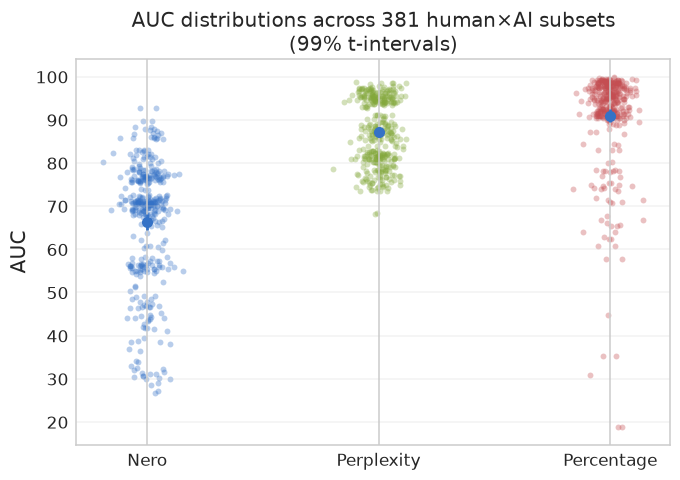

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Collect data
labels = ["Nero", "Perplexity", "Percentage"]
data = [
    np.asarray(res.auc_neroroc, dtype=float),
    np.asarray(res.auc_perplexity, dtype=float),
    np.asarray(res.auc_percentage, dtype=float),
]

means, los, his = [], [], []
for x in data:
    m, lo, hi = mean_ci(x)
    means.append(m)
    los.append(lo)
    his.append(hi)

xpos = np.arange(len(labels))

plt.figure(figsize=(7,5))

# Scatter points with jitter
rng = np.random.default_rng(0)
for i, x in enumerate(data):
    x = x[~np.isnan(x)]
    jitter = rng.normal(0, 0.05, size=len(x))
    plt.scatter(
        np.full_like(x, xpos[i]) + jitter,
        x,
        alpha=0.35,
        s=18,
        linewidths=0
    )

# Error bars (mean ± CI)
yerr = np.vstack([
    np.array(means) - np.array(los),
    np.array(his) - np.array(means)
])

plt.errorbar(
    xpos,
    means,
    yerr=yerr,
    fmt='o',
    capsize=6,
    markersize=8,
    linewidth=2,
    zorder=10
)

plt.xticks(xpos, labels)
plt.ylabel("AUC")
plt.title(f"AUC distributions across 381 human×AI subsets\n({pct}% t-intervals)")
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


In [24]:
res

,humans,ais,n_humans,n_ais,auc_neroroc,auc_percentage,auc_perplexity,auc_mean
131,"(human2,)","(ai4,)",1,1,72.139341,98.746499,97.008840,89.298227
255,"(human1, human2)","(ai1,)",2,1,87.911065,97.336980,80.974849,88.740965
1,"(human1,)","(ai1,)",1,1,87.862985,97.367049,80.834459,88.688165
149,"(human2,)","(ai3, ai4)",1,2,70.611947,97.885930,97.045549,88.514475
142,"(human2,)","(ai1, ai4)",1,2,65.868781,98.443933,96.847452,87.053389
...,...,...,...,...,...,...,...,...
182,"(human2,)","(ai2, ai3, ai6)",1,3,28.946062,67.621468,98.508462,65.025331
148,"(human2,)","(ai2, ai6)",1,2,26.728832,66.182758,98.593737,63.835109
140,"(human2,)","(ai1, ai2)",1,2,31.124328,62.921048,96.909293,63.651556
145,"(human2,)","(ai2, ai3)",1,2,38.447803,44.679522,98.284255,60.470527


In [25]:
import numpy as np
import pandas as pd

# ---- 1) scatter points (jittered) dataframe ----
labels = ["Nero", "Perplexity", "Percentage"]
data = [
    np.asarray(res.auc_neroroc, dtype=float),
    np.asarray(res.auc_perplexity, dtype=float),
    np.asarray(res.auc_percentage, dtype=float),
]

rng = np.random.default_rng(0)

rows = []
for i, (lab, x) in enumerate(zip(labels, data)):
    x = x[~np.isnan(x)]
    jitter = rng.normal(0, 0.05, size=len(x))
    for y, j in zip(x, jitter):
        rows.append(
            {
                "metric": lab,
                "x_center": i,          # integer category position
                "x_jitter": float(j),   # jitter added
                "x": float(i + j),      # final x used in scatter
                "auc": float(y),
            }
        )

df_scatter = pd.DataFrame(rows)
df_scatter.to_csv("auc_scatter_pgf.csv", index=False)

# ---- 2) summary (mean + CI) dataframe ----
summ_rows = []
for i, lab in enumerate(labels):
    mu, lo, hi = mean_ci(df_scatter.loc[df_scatter.metric == lab, "auc"].values)
    summ_rows.append(
        {
            "metric": lab,
            "x": i,
            "mean": float(mu),
            "ci_lo": float(lo),
            "ci_hi": float(hi),
            "err_lo": float(mu - lo),   # for pgfplots y error bars if desired
            "err_hi": float(hi - mu),
            "alpha": float(alpha),
            "pct": int(pct),
            "n": int(df_scatter.loc[df_scatter.metric == lab, "auc"].shape[0]),
        }
    )

df_summary = pd.DataFrame(summ_rows)
df_summary.to_csv("auc_summary_pgf.csv", index=False)

print("Wrote:", "auc_scatter_pgf.csv", "auc_summary_pgf.csv")
display(df_summary)
display(df_scatter)


Wrote: auc_scatter_pgf.csv auc_summary_pgf.csv


,metric,x,mean,ci_lo,ci_hi,err_lo,err_hi,alpha,pct,n
0,Nero,0,66.311158,64.410952,68.211364,1.900206,1.900206,0.01,99,381
1,Perplexity,1,87.055784,86.057716,88.053852,0.998068,0.998068,0.01,99,381
2,Percentage,2,90.974590,89.442785,92.506395,1.531805,1.531805,0.01,99,381


,metric,x_center,x_jitter,x,auc
0,Nero,0,0.006287,0.006287,72.139341
1,Nero,0,-0.006605,-0.006605,87.911065
2,Nero,0,0.032021,0.032021,87.862985
3,Nero,0,0.005245,0.005245,70.611947
4,Nero,0,-0.026783,-0.026783,65.868781
...,...,...,...,...,...
1138,Percentage,2,-0.014901,1.985099,67.621468
1139,Percentage,2,-0.014279,1.985721,66.182758
1140,Percentage,2,-0.028329,1.971671,62.921048
1141,Percentage,2,-0.007679,1.992321,44.679522


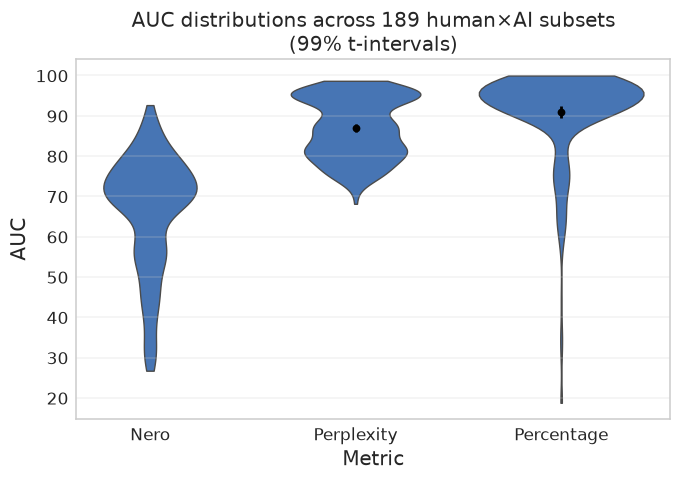

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare long-form dataframe
df_plot = pd.DataFrame({
    "AUC": np.concatenate([
        np.asarray(res.auc_neroroc, dtype=float),
        np.asarray(res.auc_perplexity, dtype=float),
        np.asarray(res.auc_percentage, dtype=float),
    ]),
    "Metric": (
        ["Nero"] * len(res.auc_neroroc)
        + ["Perplexity"] * len(res.auc_perplexity)
        + ["Percentage"] * len(res.auc_percentage)
    )
}).dropna()

plt.figure(figsize=(7,5))

sns.violinplot(
    data=df_plot,
    x="Metric",
    y="AUC",
    inner=None,          # no quartile bars
    cut=0,               # don't extend beyond data
    linewidth=1
)

# Overlay mean + CI
metrics = ["NeuroROC", "Perplexity", "Percentage"]
for i, m in enumerate(metrics):
    vals = df_plot.loc[df_plot.Metric == m, "AUC"].values
    mu, lo, hi = mean_ci(vals)
    plt.errorbar(
        i,
        mu,
        yerr=[[mu - lo], [hi - mu]],
        fmt="o",
        color="black",
        capsize=6,
        linewidth=2,
        zorder=10
    )

plt.ylabel("AUC")
plt.title(f"AUC distributions across 189 human×AI subsets\n({pct}% t-intervals)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# Classifier 

In [27]:
def func(Z,name_):
    if name_ in ['svm','gaussianp']:
        return Z[:,XSEL]
    return Z
y=df_.label.values+0
X=df_.drop(['perplexity','percentage','label'],axis=1).values

In [28]:
## We are prepraing a classification test train split, where we dont include the latest ai models at all for training to test future-proofness

df_for_classifier=pd.concat([human1,human2,ai0,ai1,ai2,ai3,ai4,ai5])
df_for_classifier_ai_test_future=pd.concat([ai6])

# Full classification pool
df_classification = df_for_classifier.reset_index(drop=True)

# Reproducibility
rng = np.random.default_rng(42)

# Randomly select half the rows for training
n = len(df_classification)
train_idx = rng.choice(n, size=n // 2, replace=False)

df_train = df_classification.iloc[train_idx]

# The remaining half becomes part of the test set
df_test_in_domain = df_classification.drop(train_idx)

# Final test set = remaining half + future AI data
df_test = pd.concat(
    [df_test_in_domain, df_for_classifier_ai_test_future],
    axis=0,
    ignore_index=True
)
X_train = df_train.drop(['perplexity','percentage','label'],axis=1).values
y_train = df_train.label.values+0
X_test = df_test.drop(['perplexity','percentage','label'],axis=1).values
y_test = df_test.label.values+0

#display(df_train)
#display(df_test)

In [29]:
df_.columns

Index(['perplexity', 'percentage', 'entropy_rate', 'rates_0', 'rates_1',
       'rates_2', 'rates_3', 'rates_4', 'rates_5', 'rates_6', 'rates_7',
       'rates_8', 'rates_9', 'rates_10', 'rates_11', 'rates_12', 'rates_13',
       'rates_14', 'rates_15', 'rates_16', 'rates_17', 'rates_18', 'rates_19',
       'rates_20', 'rates_21', 'rates_22', 'rates_23', 'rates_24', 'rates_25',
       'rates_26', 'rates_27', 'rates_28', 'rates_29', 'rates_30', 'rates_31',
       'rates_32', 'rates_33', 'rates_34', 'rates_35', 'rates_36', 'rates_37',
       'rates_38', 'rates_39', 'rates_40', 'label', 'nz_entropy_rate',
       'nzmean', 'nzstd', 'nzero'],
      dtype='str')

In [30]:
%%time
from sklearn import metrics
IMPUTE=True

if IMPUTE:
    from sklearn.impute import SimpleImputer
    # Impute missing values with zeros
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.fit_transform(X_test)
    X = imputer.fit_transform(X)
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

modelnames=[
    'randomforest',
    #'extratrees','adaboost','gradientboost','svm',
    'gaussianp']
models = [RandomForestClassifier(n_estimators = 2500,class_weight='balanced').fit(X_train, y_train),
          #ExtraTreesClassifier(n_estimators = 2500,class_weight='balanced').fit(X_train, y_train),
          #AdaBoostClassifier(n_estimators=2000).fit(X_train, y_train),
          #GradientBoostingClassifier(n_estimators = 2500).fit(X_train, y_train),
          #svm.SVC(probability=True).fit(X_train, y_train),
         GaussianProcessClassifier(kernel=1.0 * RBF(1.0)).fit(X_train, y_train)
         ]
y_preds = [model.predict_proba(X_test) for model,modelname in zip(models,modelnames)]
auc_scores={}
ROC={}
for modelname,y_pred in zip(modelnames,y_preds):
    fpr, tpr, thresholds = metrics.roc_curve(y_test,y_pred[:,1] , pos_label=1)
    auc_scores[modelname] = auc(fpr, tpr)
    ROC[modelname]={'fpr':fpr,'tpr':tpr,'thresholds':thresholds}
print(auc_scores)

{'randomforest': 0.9198607025751585, 'gaussianp': 0.9950812028850154}
CPU times: user 10min 16s, sys: 16.8 s, total: 10min 33s
Wall time: 1min 26s


<Axes: >

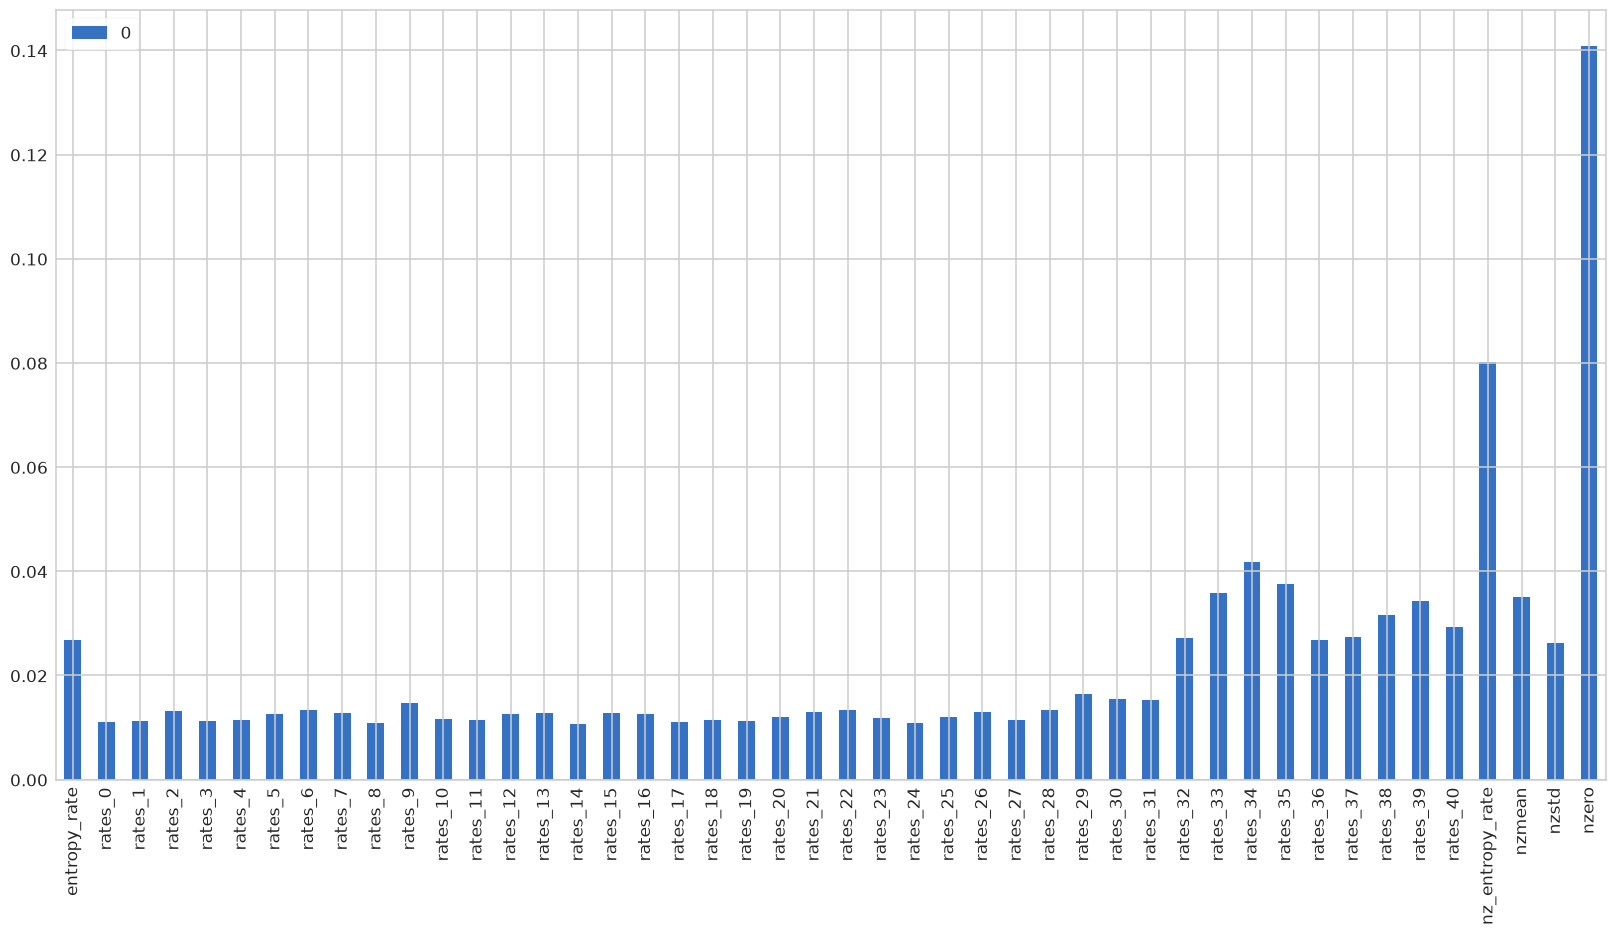

In [31]:
plt.figure(figsize=[20,10])
pd.DataFrame(models[0].feature_importances_,[x for x in df_.columns if x not in ['perplexity','percentage', 'label']]).plot(ax=plt.gca(),kind='bar')


In [32]:
modeldf_=[pd.DataFrame(ROC[model_]) for model_ in modelnames]
ztc=zedstat.processRoc(df=modeldf_[-1],
           order=3, 
           total_samples=len(y_test),
           positive_samples=y_test.sum(),
           alpha=0.01,
           prevalence=.5)

ztc.smooth(STEP=0.001)
ztc.allmeasures(interpolate=True)
ztc.usample(precision=2)
ztc.getBounds()

auc_c=np.array(ztc.auc(alpha=.05))*100
deltac=(auc_c[1]-auc_c[2])/2
lc=str(auc_c[0])[:4]+'%'
ztc.auc(alpha=.05)

(0.9928956985680595,
 np.float64(0.9961843689619512),
 np.float64(0.9896070281741678))

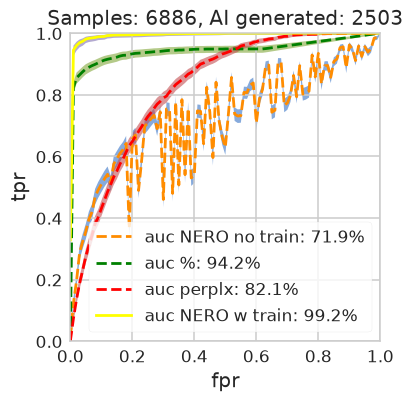

In [33]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
ax=ztpc.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
ax=ztpx.get().tpr.plot(style='--',ax=ax,color='red',lw=2)
ax=ztc.get().tpr.plot(style='-',ax=ax,color='yellow',lw=2)

plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpc.get().index, y1=ztpc.df_lim['U'].tpr,y2=ztpc.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpx.get().index, y1=ztpx.df_lim['U'].tpr,y2=ztpx.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztc.get().index, y1=ztc.df_lim['U'].tpr,y2=ztc.df_lim['L'].tpr, alpha=.6)


dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_notraining.csv')
dx=pd.DataFrame({'tpr_upper':ztpc.df_lim['U'].tpr,'tpr_lower':ztpc.df_lim['L'].tpr}).join(ztpc.get()['tpr'])
dx.to_csv('percentage_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztpx.df_lim['U'].tpr,'tpr_lower':ztpx.df_lim['L'].tpr}).join(ztpx.get()['tpr'])
dx.to_csv('perplexity_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztc.df_lim['U'].tpr,'tpr_lower':ztc.df_lim['L'].tpr}).join(ztc.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_trained.csv')


ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO no train: '+le,'auc %: '+lpc,'auc perplx: '+lpx, 'auc NERO w train: '+lc],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining'+SUBSET+'.pdf',bbox_inches='tight',transparent=True)